# 1、采用fem spring刚度代替水动力刚度计算位移。转化矩阵结果导致fem spring 数值太大，位移去向于0。2024年1月2日17:03:35
## 2、 对比湿模态，对程序进行修改。运行成功获得一个新的结果，对比结果不错

In [1]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP

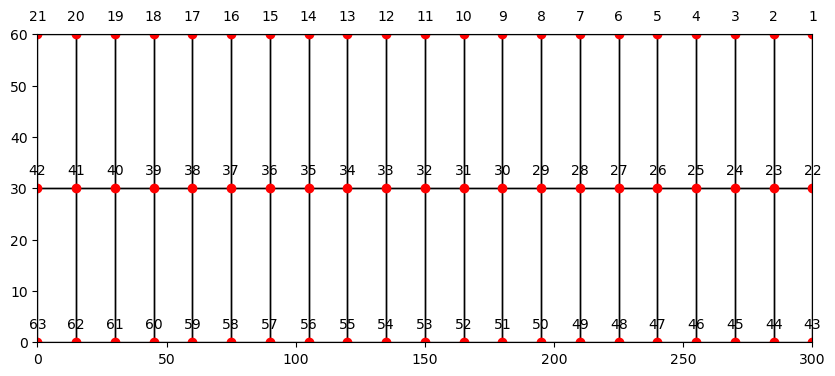

In [2]:
# Show nodes and node message
file_path = "E:\phd\Code\DM-FEM2D\Fem_inp\Job-1_largemesh.inp"
label_interval = 1
node = DMshow.plot_fea_model(file_path, label_interval)
#node_ids = [41, 39, 37, 35, 33, 31, 29, 27, 25, 23]

In [ ]:
# define parameters
num_nodes = 63 # 63 793
master_nodes = [41, 39, 37, 35, 33, 31, 29, 27, 25, 23]  #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10)
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\DM10_120_direction0.nc"))
omega = dataset.omega.values
Area = 30*15
nodes_per_row = 21
# read mass and stiffness matrix
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_largemesh_ConsistentMass_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_largemesh_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])
hydrostatic_stiffness = SEREP.get_fem_spring_stiffness(num_nodes, nodes_per_row, Area)
hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,num_nodes,[5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
MR,KR,T = SEREP.SEREP(k+hydrostatic_stiffness, M, SlaveDofs)
# read hydrodynamic data
added_mass = dataset['added_mass'][0].values
radiation_damping = dataset['radiation_damping'][0].values
inertia_matrix = dataset['inertia_matrix'].values

F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values
# REDUCE THE MATRICES
added_mass = SEREP.reduce_dofs(added_mass,10,[5])
radiation_damping = SEREP.reduce_dofs(radiation_damping,10,[5])
# hyrostatic stiffness or fem spring stiffness
# 1. choice hydrostatic stiffness
# hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
# hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,10,[5])
# 2. choice fem spring stiffness

# hydrostatic_stiffness = T.T @ hydrostatic_stiffness @ T

inertia_matrix = SEREP.reduce_dofs(inertia_matrix,10,[5])
F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1,50)
# F_w = F_w.reshape(10,5)[::-1].reshape(1,50)
# Generate the system matrices
mass = added_mass + MR
damping = radiation_damping
stiffness = KR
# Solve in frequency domain
master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)
# Restore global displacement under disorder masterdofs and slavedofs
global_displacement_disorder = T @ master_displacement
# Reorder global displacement under order
global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

TypeError: SEREP() missing 1 required positional argument: 'master_nodes'

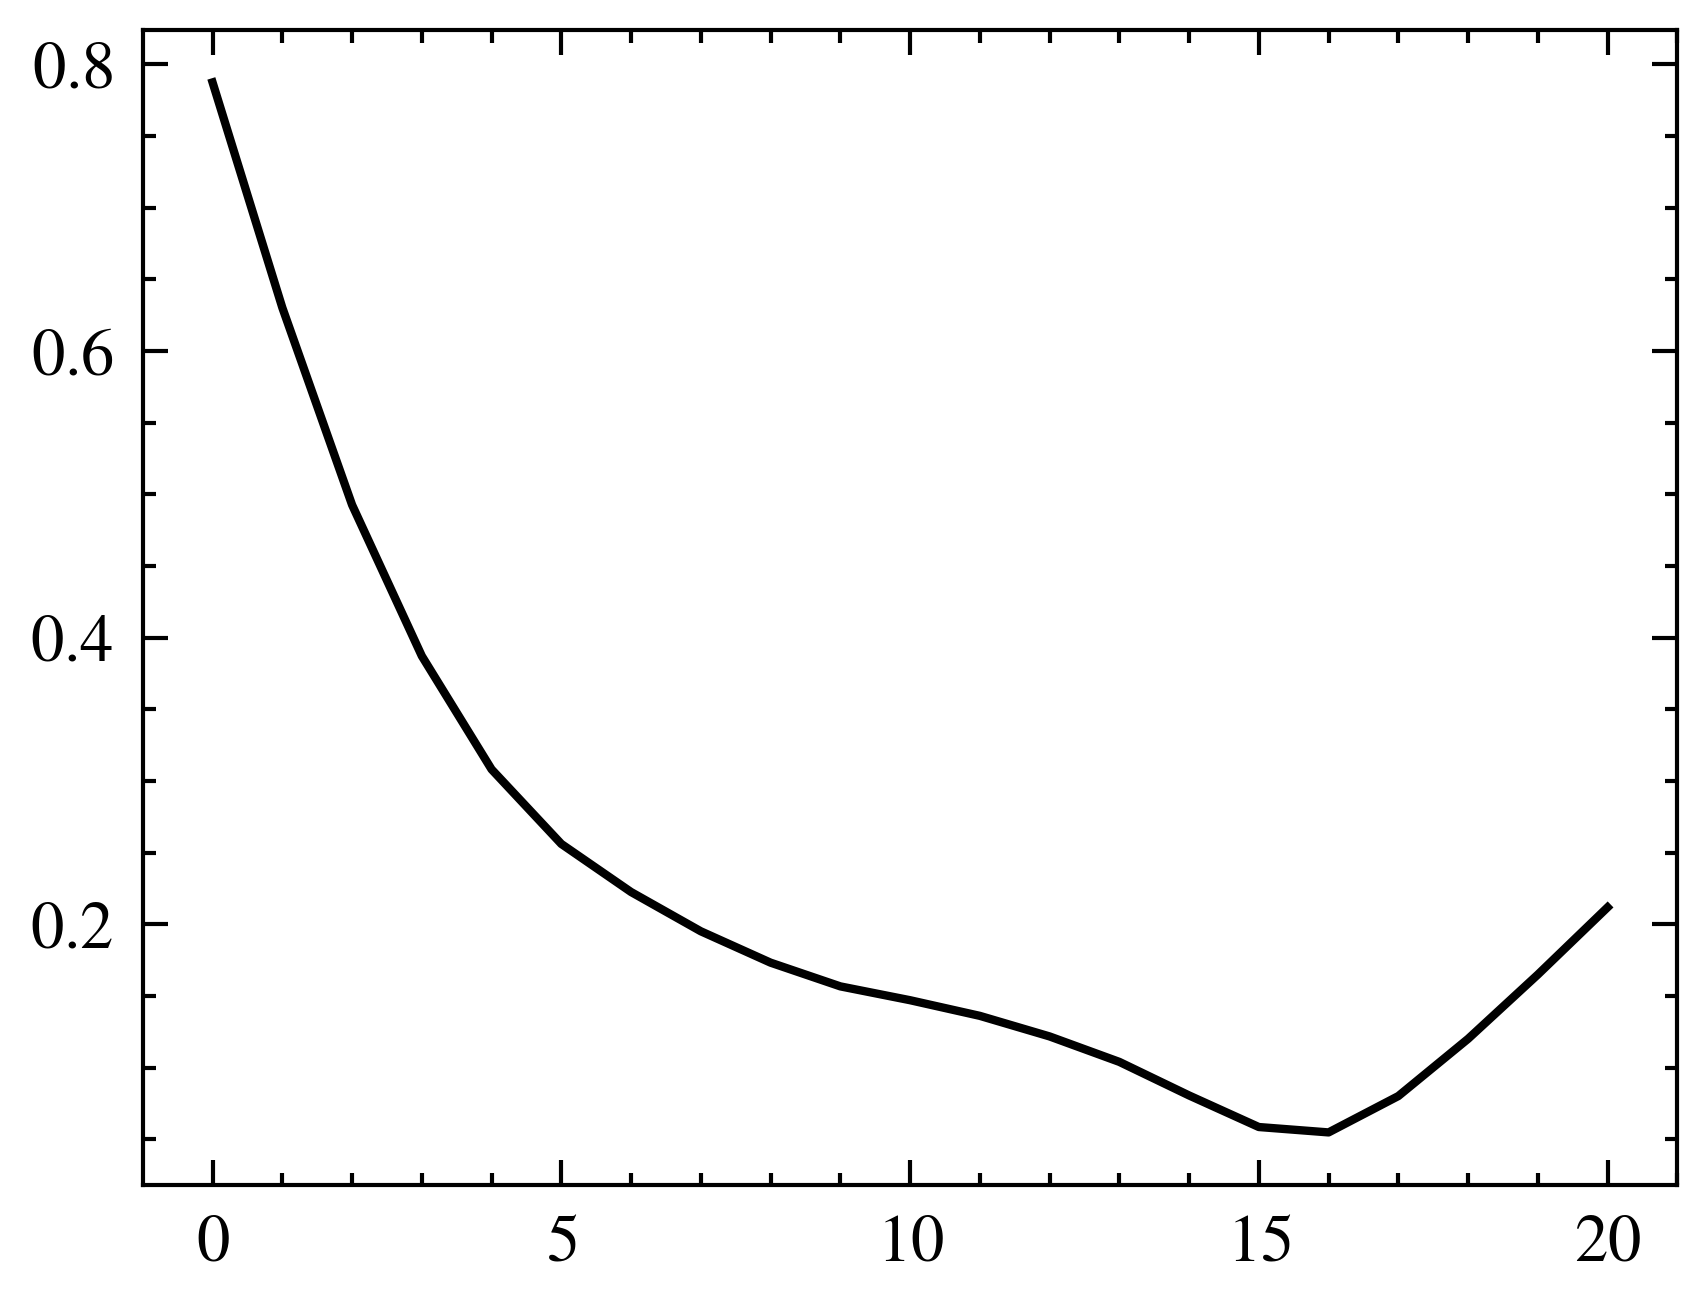

In [11]:
import matplotlib.pyplot as plt
mid = global_displacement[22*5-5:43*5-5,:]
heave = abs(mid[2::5])
plt.plot(abs(mid[2::5]), label="Present")

## 验证工作

Text(0, 0.5, 'Heave RAO ($m$/$m$)')

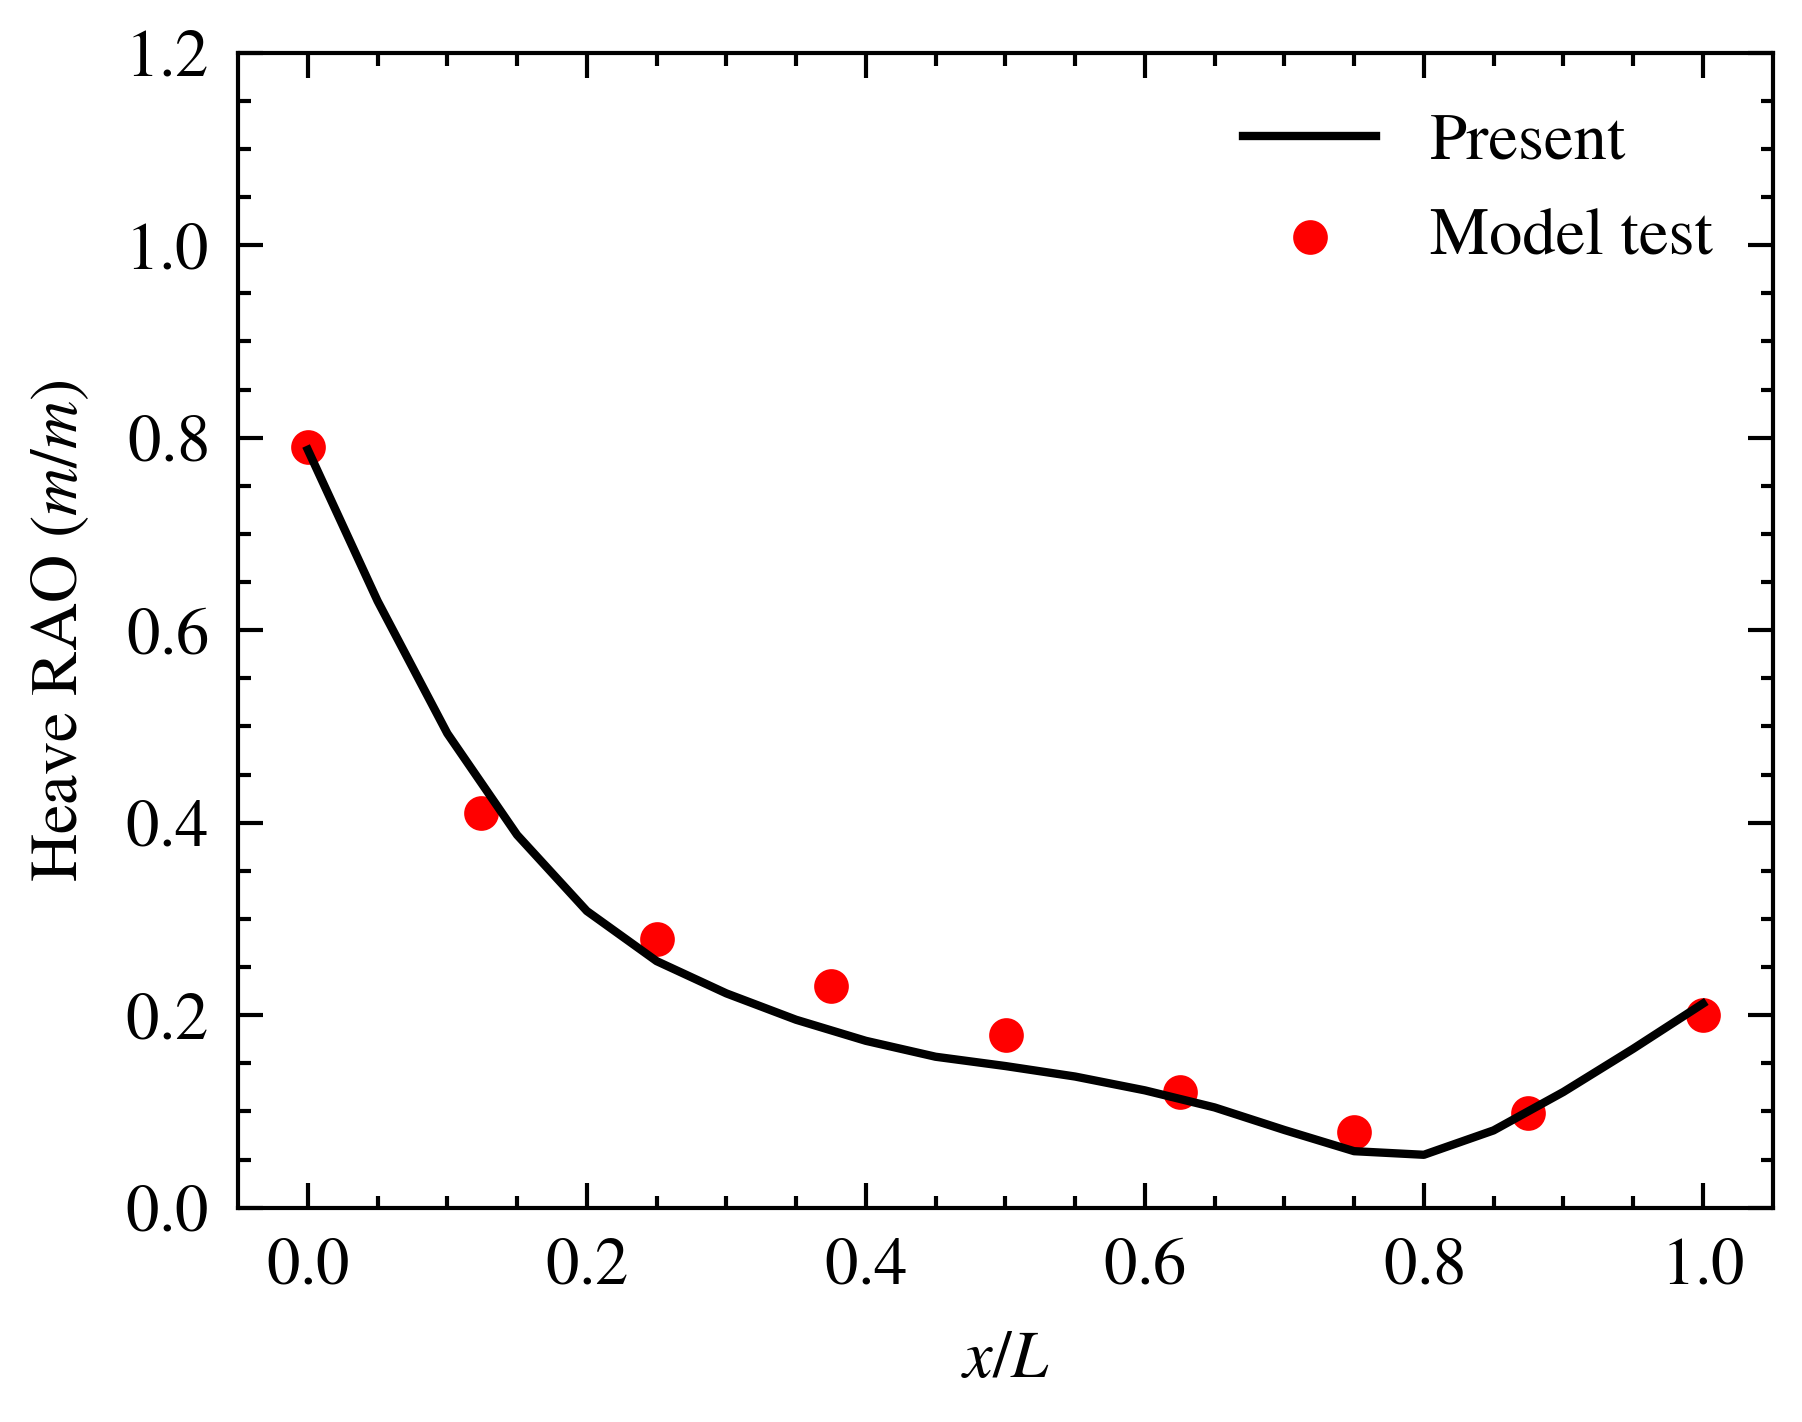

In [12]:
import matplotlib.pyplot as plt
mid = global_displacement[22*5-5:43*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_120.txt")
y = np.array(y)
# 绘图
import scienceplots
x1 = np.linspace(0,1,21)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,abs(mid[2::5]), label="Present")
plt.scatter(x,y,color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,1.2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

In [ ]:
import matplotlib.pyplot as plt
mid = global_displacement[367*5-5:427*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_120.txt")
y = np.array(y)
# 绘图
import scienceplots
x1 = np.linspace(0,1,60)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,abs(mid[2::5]), label="Present")
plt.scatter(x,y[::-1],color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,1.2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

## 2.1 check 模态

In [9]:
1025*9.81*30*15/4

1131215.625

In [ ]:
11374655913.28125